# Electricidad y Magnetismo
Vamos a estar trabajando con las ecuaciones del vacío. Tenemos un potenial eléctrico $U(\vec{r})$ generado por una densidad de carga $\rho(\vec{r})$ y satisface la ecuación:
\begin{equation}
\nabla^2 U(\vec{r}) = -\frac{\rho(\vec{r})}{\epsilon_0}
\end{equation}
Para el caso donde la densidad de carga sea nula, obtenemos el caso de la **Ecuación de Laplace**. Para 2D, tenemos una ecuación diferencial parcial:
\begin{equation}
\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2} = -\frac{\rho(x,y)}{\epsilon_0}
\end{equation}
Si discretizamos la ecuación de Laplace:
\begin{equation}
U_{i+1,j} + U_{i-1,j} - 2U_{i,j} + U_{i,j+1}+U_{i,j-1}-2U_{i,j} = 0
\end{equation}
$$U_{i,j} = \frac{U_{i+1,j} + U_{i-1,j} + U_{i,j+1}+U_{i,j-1}}{4}+\frac{\Delta x^2\rho_{i,j}}{4\epsilon_0}$$
La interpretación es que el potencial en un punto es el promediado del valor de sus 4 vecinos más una contribución dada por la densidad de carga.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Método de Jacobi
Actualizamos todos los puntos simultáneamente, usa únicamente valores de la iteración anterior, y conserva mejor la simetría del problema:
$$U_{i,j}^{n+1} = \frac{1}{4}\left(U^n_{i+1,j} + U^n_{i-1,j} + U^n_{i,j+1}+U^n_{i,j-1}\right)$$
# Método de Gauss - Seidel
Usa los valores recién calculados, converge más rápido pero puede romper ciertas simetrías numéricas:
$$U_{i,j}^{n+1} = \frac{1}{4}\left(U^{n+1}_{i+1,j} + U^{n+1}_{i-1,j} + U^{n+1}_{i,j+1}+U^{n+1}_{i,j-1}\right)$$


Problema:
## Potencial eléctrico sobre una región cuadrada libre de carga:
- Su frontera superior se mantiene a 100V
- Sus lados y parte inferior se encuentran aterrizados (0V)

In [ ]:
Nx = 50
Ny = 50

h = 0.1
tol = 1e-4
max_iterations = int(10000)
V01 = 100
V02 = 0

u = np.zeros((Nx, Ny))
#Extremo superior
u[:,Ny - 1] = V01
#Extremos laterales e inferior
u[0, 1:] = V02
u[Nx - 1, 1:] = V02
u[1:-2, 0]  = V02

#Gauss-Scheffel
for iteration in range(max_iterations):
    uold = u.copy()
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            u[i, j] = (u[i + 1, j] + u[i - 1, j] + u[i, j + 1] + u[i, j - 1]) / 4
    
        error = np.max(np.abs(u - uold))
    if iteration % 100 == 0:
        print('Iteración: ', iteration, 'Error: ', error)

    if error < tol: 
        print('Tolerancia alcanzada')
        break
    
    #if error < 1e-4:
    #    print('Convergencia alcanzada')
    #    break    
    


Iteración:  0 Error:  33.33333333333333
Iteración:  100 Error:  0.24569165168807316
Iteración:  200 Error:  0.10512589076340006
Iteración:  300 Error:  0.057586885533119414
Iteración:  400 Error:  0.035165537616890674
Iteración:  500 Error:  0.0226086017604743
Iteración:  600 Error:  0.014844207865102987
Iteración:  700 Error:  0.009819921857346259
Iteración:  800 Error:  0.006503719551659515
Iteración:  900 Error:  0.004312447275125919
Iteración:  1000 Error:  0.002858838777076045
Iteración:  1100 Error:  0.0018949793335032439
Iteración:  1200 Error:  0.0012560065905553586
Iteración:  1300 Error:  0.0008324624061231134
Iteración:  1400 Error:  0.0005517335667128975
Iteración:  1500 Error:  0.00036567048380575784
Iteración:  1600 Error:  0.0002423528327817337
Iteración:  1700 Error:  0.0001606220081811216
Iteración:  1800 Error:  0.00010645384006124914
Tolerancia alcanzada


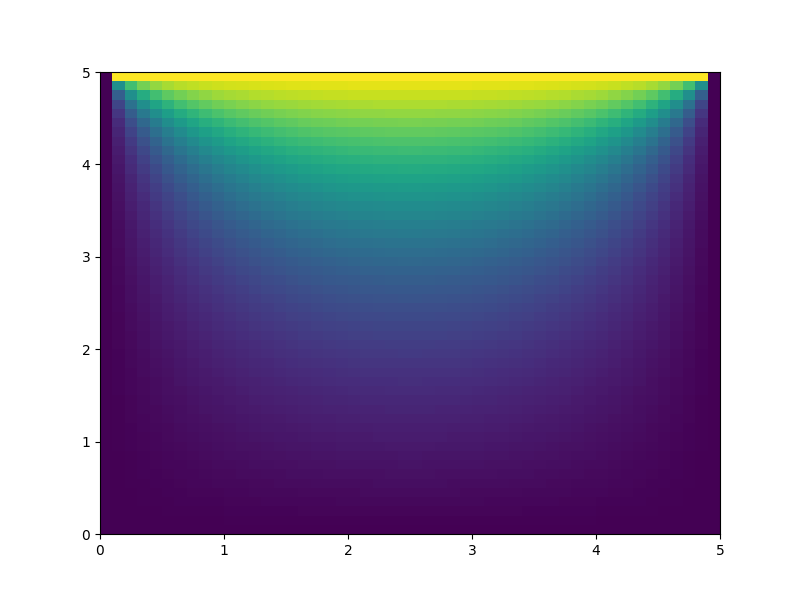

In [14]:
#malla
x = np.arange(0, Nx) * h
y = np.arange(0, Ny) * h

X, Y = np.meshgrid(x, y)
plt.figure(figsize=(8,6))
plt.imshow(
            u.T,
            origin = 'lower',
            extent = [0, Nx * h, 0, Ny * h],
            aspect = 'auto'
)
plt.show()

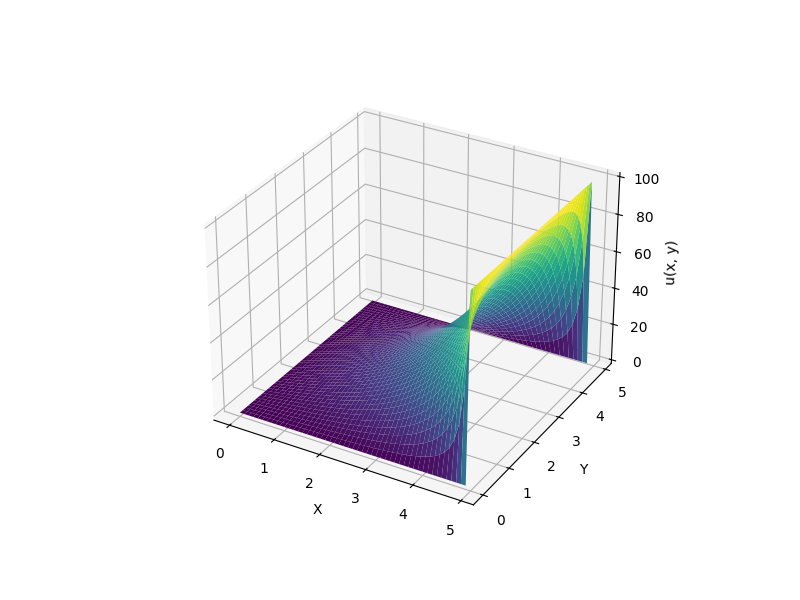

In [15]:
from mpl_toolkits.mplot3d import Axes3D
x = np.arange(0, Nx, 1) * h
y = np.arange(0, Ny, 1) * h

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, u, cmap = 'viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(x, y)')

plt.show()

In [17]:
u = np.zeros((Nx, Ny))
#Extremo superior
u[:,Ny - 1] = V01
#Extremos laterales e inferior
u[0, 1:] = V02
u[Nx - 1, 1:] = V02
u[1:-2, 0]  = V02

for iteration in range(max_iterations):
    uold = u.copy()
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            uold[i, j] = (u[i + 1, j] + u[i - 1, j] + u[i, j + 1] + u[i, j - 1]) / 4
    
        error = np.max(np.abs(u - uold))
    if iteration % 100 == 0:
        print('Iteración: ', iteration, 'Error: ', error)

    if error < tol: 
        print('Tolerancia alcanzada')
        break
    u = uold.copy()

Iteración:  0 Error:  25.0
Iteración:  100 Error:  0.23942973354873232
Iteración:  200 Error:  0.11690367949715608
Iteración:  300 Error:  0.07296495539043235
Iteración:  400 Error:  0.05022053205884447
Iteración:  500 Error:  0.03652024059443448
Iteración:  600 Error:  0.027538860280337474
Iteración:  700 Error:  0.021319238858964695
Iteración:  800 Error:  0.01680989796104626
Iteración:  900 Error:  0.013417048802164544
Iteración:  1000 Error:  0.010795321310869355
Iteración:  1100 Error:  0.008726351745153238
Iteración:  1200 Error:  0.007080896304103135
Iteración:  1300 Error:  0.005750793209962524
Iteración:  1400 Error:  0.004676873225751166
Iteración:  1500 Error:  0.0038057978060450637
Iteración:  1600 Error:  0.0030973003410039723
Iteración:  1700 Error:  0.002520908747381867
Iteración:  1800 Error:  0.0020519089713744165
Iteración:  1900 Error:  0.0016702414423228618
Iteración:  2000 Error:  0.0013596131798898625
Iteración:  2100 Error:  0.0011067830537285772
Iteración:  2200

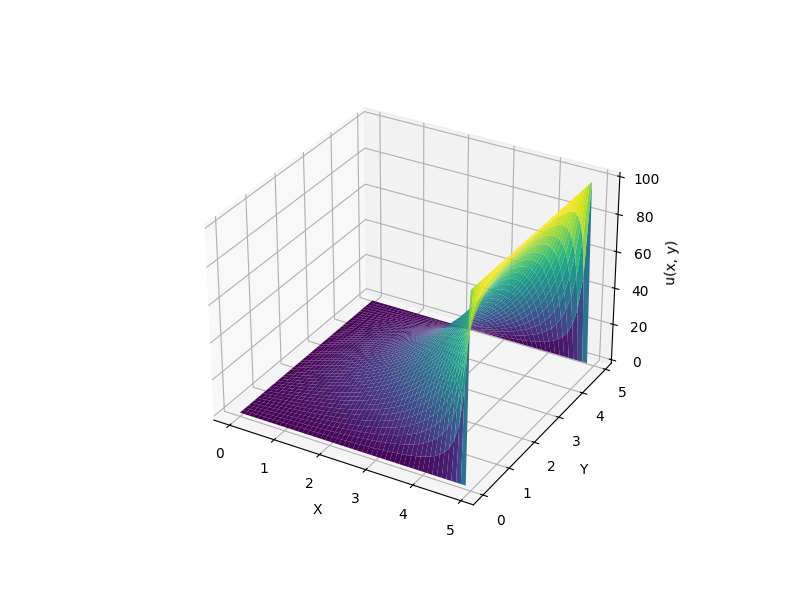

In [18]:
from mpl_toolkits.mplot3d import Axes3D
x = np.arange(0, Nx, 1) * h
y = np.arange(0, Ny, 1) * h

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, u, cmap = 'viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(x, y)')

plt.show()

# Dos placas cargadas
Consideremos un capacitor de placas paralelas dentro de una caja conductora aterrizada, las cuales son muy delgadas:
$$V_{sup} = 100 V$$
$$V_{inf} = -100 V$$
La caja externa está aterrizada ($V = 0$).
Para el caso de un capacitor ideal: $\vec{E} = cte$

In [25]:
Ny = 100
Nx = 100
d = 10
V1 = 100
V2 = -100
V0 = 0

tol = 1e-4
max_iterations = 10000

U = np.zeros((Nx, Ny))
#máscara para identificar placas
mask = np.zeros((Nx, Ny))

#definición de placas dle capacitor
U[30, 30:70] = V1
mask[30, 30:70] = 1

#placa inferior
U[60, 30:70] = V2
mask[60, 30:70] = 1

In [26]:
#Gaus - Siedel
for iteration in range(max_iterations):
    Uold = U.copy()
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            #No modificar placas
            if mask[i, j] == 0:
                U[i, j] = (U[i + 1, j] + U[i - 1, j] + U[i, j + 1] + U[i, j - 1]) / 4
            
    error = np.max(np.abs(U - Uold))
    if iteration % 100 == 0:
        print('Iteración: ', iteration, 'Error: ', error)

    if error < tol: 
        print('Tolerancia alcanzada')
        break

Iteración:  0 Error:  33.33333333333333
Iteración:  100 Error:  0.24461077980418366
Iteración:  200 Error:  0.10935403762865192
Iteración:  300 Error:  0.06405877048450392
Iteración:  400 Error:  0.043182435347397075
Iteración:  500 Error:  0.029875239534604248
Iteración:  600 Error:  0.0209000102198047
Iteración:  700 Error:  0.01469245007020703
Iteración:  800 Error:  0.010359463614967979
Iteración:  900 Error:  0.007317474323009776
Iteración:  1000 Error:  0.005174724641953787
Iteración:  1100 Error:  0.003662547336091393
Iteración:  1200 Error:  0.00259409507821573
Iteración:  1300 Error:  0.0018386566204071642
Iteración:  1400 Error:  0.001304027672176744
Iteración:  1500 Error:  0.0009254329022923002
Iteración:  1600 Error:  0.0006571714813574658
Iteración:  1700 Error:  0.0004669725495318744
Iteración:  1800 Error:  0.0003320447503796231
Iteración:  1900 Error:  0.00023626421445044343
Iteración:  2000 Error:  0.00016821837169800347
Iteración:  2100 Error:  0.00011984421850286253

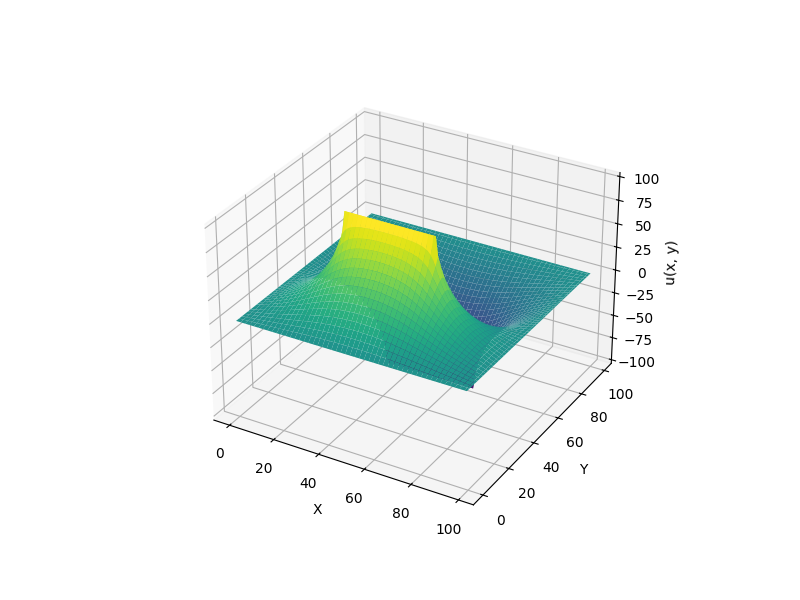

In [27]:
x = np.arange(0, Nx, 1) 
y = np.arange(0, Ny, 1) 

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, U, cmap = 'viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(x, y)')

plt.show()

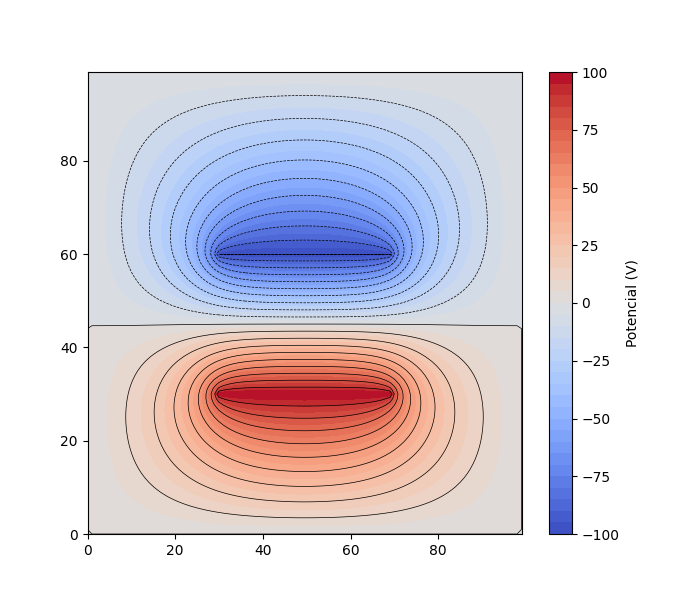

In [32]:
plt.figure(figsize=(7,6))

cont = plt.contourf(X, Y, U,
                    40, 
                    cmap = 'coolwarm')
plt.colorbar(label='Potencial (V)')
plt.contour(X, Y, U,
            20, 
            colors = 'black',
            linewidths = 0.5)
plt.show()

# Capacitor desconectado
Consideramos ahora placas que no están conectadas a una batería, como consecuencia, las placas superior e inferior poseen densidad de carga uniforme:
$$+\rho;\qquad-\rho$$
Resolvemos ahora la ecuación de Poisson:
$$\nabla^2 V = -\frac{\rho}{\epsilon_0}$$

In [45]:
Ny = 100
Nx = 100
V1 = 100
V2 = -100
V0 = 0
h = 1
rho0 = 100

tol = 1e-4
max_iterations = 10000

U = np.zeros((Nx, Ny))
rho = np.zeros((Nx, Ny))
#máscara para identificar placas
mask = np.zeros((Nx, Ny))

#definición de placas dle capacitor
#U[30, 30:70] = V1
rho[30, 30:70] = +rho0
#mask[30, 30:70] = 1

#placa inferior
#U[60, 30:70] = V2
rho[60, 30:70] = -rho0
#mask[60, 30:70] = 1

In [46]:
#Gaus - Siedel
for iteration in range(max_iterations):
    Uold = U.copy()
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            #No modificar placas
        #if mask[i, j] == 0:
            U[i, j] = (U[i + 1, j] + U[i - 1, j] + U[i, j + 1] + U[i, j - 1] + h ** 2 * rho[i, j]) / 4
            
    error = np.max(np.abs(U - Uold))
    if iteration % 100 == 0:
        print('Iteración: ', iteration, 'Error: ', error)

    if error < tol: 
        print('Tolerancia alcanzada')
        break

Iteración:  0 Error:  33.33333333333333
Iteración:  100 Error:  1.8913568149518483
Iteración:  200 Error:  1.1021256889125652
Iteración:  300 Error:  0.7261496519183197
Iteración:  400 Error:  0.507504362725058
Iteración:  500 Error:  0.3832019469170973
Iteración:  600 Error:  0.29775706876307595
Iteración:  700 Error:  0.2350279000634714
Iteración:  800 Error:  0.18713351473616058
Iteración:  900 Error:  0.14999657495326346
Iteración:  1000 Error:  0.12085066520489818
Iteración:  1100 Error:  0.09784615820171894
Iteración:  1200 Error:  0.07961166139182296
Iteración:  1300 Error:  0.06515519053385788
Iteración:  1400 Error:  0.0536082611938582
Iteración:  1500 Error:  0.044371624182986125
Iteración:  1600 Error:  0.03696436657173763
Iteración:  1700 Error:  0.03099780745276348
Iteración:  1800 Error:  0.026165452907321196
Iteración:  1900 Error:  0.02224531041690625
Iteración:  2000 Error:  0.019043542016902393
Iteración:  2100 Error:  0.016412089736149937
Iteración:  2200 Error:  0.0

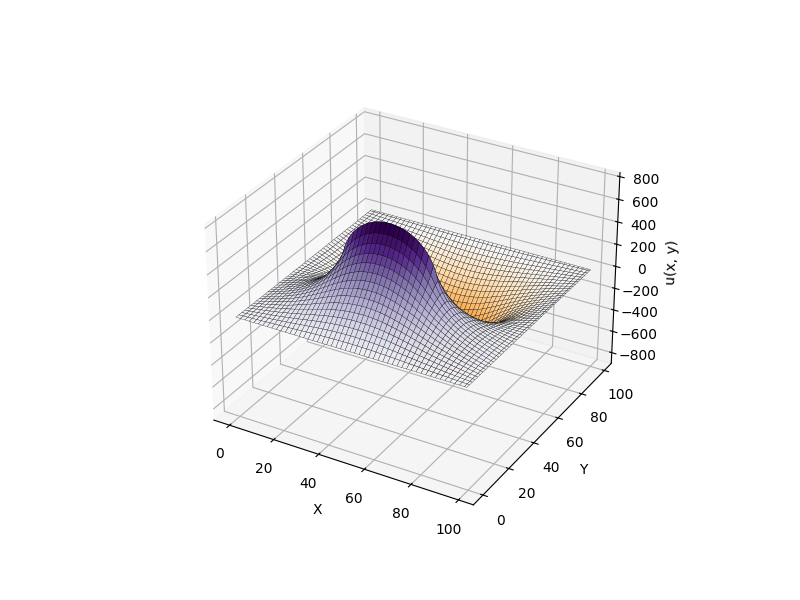

In [48]:
x = np.arange(0, Nx, 1) 
y = np.arange(0, Ny, 1) 

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, U, cmap = 'PuOr', edgecolor = 'k', linewidth = 0.2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(x, y)')

plt.show()

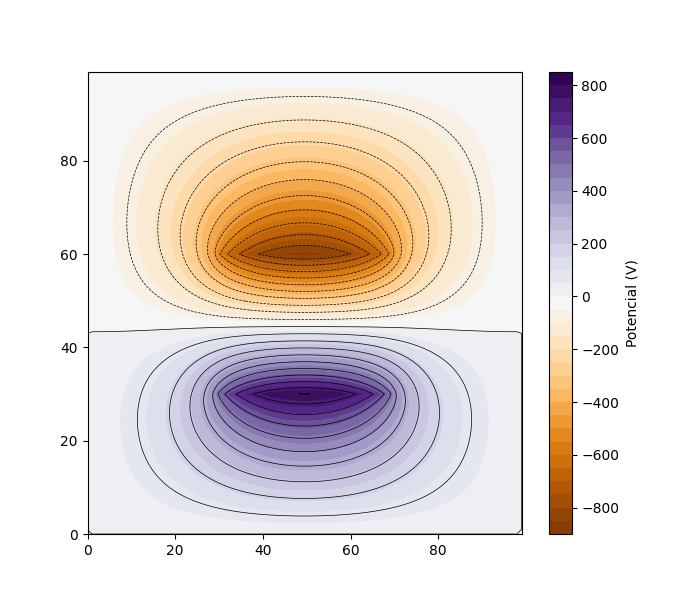

In [49]:
plt.figure(figsize=(7,6))

cont = plt.contourf(X, Y, U,
                    40, 
                    cmap = 'PuOr')
plt.colorbar(label='Potencial (V)')
plt.contour(X, Y, U,
            20, 
            colors = 'black',
            linewidths = 0.5)
plt.show()